In [2]:
# Cell 1 — (Opsiyonel ama önerilir) Drive bağla
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 2 — Repo'yu güncel çek (visual branch)
%cd /content
!rm -rf COMP547PROJECT
!git clone -b visual https://github.com/oaydogdu/COMP547PROJECT.git
%cd /content/COMP547PROJECT
!git log -1 --oneline

In [4]:
# Cell 3 — Ortam kurulumu
!python -V
!nvidia-smi
!pip install -r requirements.txt

Python 3.12.13
Sat May  2 12:15:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+--------------------------------

In [ ]:
# Cell 4 — GPU doğrulama
import torch
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

train 1/15: 100%|██████████| 234/234 [00:35<00:00,  6.64it/s, bpd=3.3733]


epoch=1 train_bpd=3.7001 test_bpd=3.3879


train 2/15: 100%|██████████| 234/234 [00:35<00:00,  6.66it/s, bpd=3.1983]


epoch=2 train_bpd=3.3408 test_bpd=3.1925


train 3/15: 100%|██████████| 234/234 [00:35<00:00,  6.67it/s, bpd=3.0961]


...

epoch=13 train_bpd=2.8907 test_bpd=2.8418


train 14/15: 100%|██████████| 234/234 [00:35<00:00,  6.66it/s, bpd=2.8940]


epoch=14 train_bpd=2.8824 test_bpd=2.8429


train 15/15: 100%|██████████| 234/234 [00:35<00:00,  6.67it/s, bpd=2.8594]


epoch=15 train_bpd=2.8741 test_bpd=2.8332

Checkpoint saved at: results/pixelcnnpp/checkpoints/pixelcnnpp_fashion_mnist_lr0.00030_res2_f64.pt


Found 2 sample grids


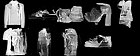

In [ ]:
# Cell 5 — 20 epoch train (Fashion-MNIST)
%cd /content/COMP547PROJECT
!PYTHONPATH=src python scripts/train_pixelcnnpp.py \
  --dataset fashion_mnist \
  --epochs 20 \
  --batch-size 16 \
  --save-dir results/pixelcnnpp_fashion_e20

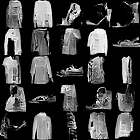

{
  "checkpoint": "results/pixelcnnpp/checkpoints/pixelcnnpp_fashion_mnist_lr0.00030_res2_f64.pt",
  "dataset": "fashion_mnist",
  "sample_batch_size": 25,
  "latency_ms_per_image": 808.6339339999995,
  "throughput_img_per_s": 1.2366535189209615,
  "note": "FID should be computed in a separate script from generated samples."
}


In [ ]:
# Cell 6 — Çıktı klasörleri kontrol
!ls -R results/pixelcnnpp_fashion_e20

In [ ]:
# Cell 7 — Eval (hız metrikleri + sample grid)
!CKPT=$(ls -t results/pixelcnnpp_fashion_e20/checkpoints/*.pt | head -n 1) && \
echo "Using checkpoint: $CKPT" && \
PYTHONPATH=src python scripts/eval_pixelcnnpp.py \
  --checkpoint "$CKPT" \
  --out-json results/pixelcnnpp_fashion_e20/eval/fashion_eval.json \
  --out-grid results/pixelcnnpp_fashion_e20/eval/fashion_grid.png \
  --sample-batch-size 25

In [ ]:
# Cell 8 — Eğitim metriklerini yükle ve son değerleri yazdır (sunum için sayısal özet)
import glob, json

metrics_files = sorted(glob.glob("results/pixelcnnpp_fashion_e20/metrics/*.json"))
assert len(metrics_files) > 0, "Metrics json bulunamadı."
metrics_path = metrics_files[-1]
print("Metrics file:", metrics_path)

with open(metrics_path, "r") as f:
    hist = json.load(f)

print(f"Total epochs logged: {len(hist)}")
print("First epoch:", hist[0])
print("Last epoch:", hist[-1])

best_test = min(hist, key=lambda x: x["test_bpd"])
print("Best test_bpd epoch:", best_test["epoch"], "value:", best_test["test_bpd"])

In [ ]:
# Cell 9 — Eval json yazdır (latency / throughput)
import json

with open("results/pixelcnnpp_fashion_e20/eval/fashion_eval.json", "r") as f:
    eval_metrics = json.load(f)

print(json.dumps(eval_metrics, indent=2))

In [ ]:
# Cell 10 — Train/Test BPD eğrisi (sunum için grafik)
import matplotlib.pyplot as plt

epochs = [x["epoch"] for x in hist]
train_bpd = [x["train_bpd"] for x in hist]
test_bpd  = [x["test_bpd"] for x in hist]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_bpd, marker="o", label="train_bpd")
plt.plot(epochs, test_bpd, marker="o", label="test_bpd")
plt.xlabel("Epoch")
plt.ylabel("Bits Per Dimension (BPD)")
plt.title("PixelCNN++ Training Curve (Fashion-MNIST, 20 Epoch)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results/pixelcnnpp_fashion_e20/eval/bpd_curve.png", dpi=180)
plt.show()

print("Saved: results/pixelcnnpp_fashion_e20/eval/bpd_curve.png")

In [ ]:
# Cell 11 — Generated sample grid'i büyük göster
from PIL import Image
import matplotlib.pyplot as plt

gen_path = "results/pixelcnnpp_fashion_e20/eval/fashion_grid.png"
gen_img = Image.open(gen_path)
print("Generated grid size:", gen_img.size)

plt.figure(figsize=(14,14))
plt.imshow(gen_img, cmap="gray")
plt.axis("off")
plt.title("Generated Samples (PixelCNN++, Fashion-MNIST, 20 Epoch)")
plt.show()

In [ ]:
# Cell 12 — Generated sample'ları tek tek büyük göster (5x5)
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("results/pixelcnnpp_fashion_e20/eval/fashion_grid.png").convert("L")
arr = np.array(img)

nrow = 5
H, W = arr.shape
cell_h, cell_w = H // nrow, W // nrow

fig, axes = plt.subplots(nrow, nrow, figsize=(12,12))
for i in range(nrow):
    for j in range(nrow):
        patch = arr[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
        axes[i, j].imshow(patch, cmap="gray")
        axes[i, j].axis("off")
plt.suptitle("Generated Samples (Individual View)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13 — Real vs Generated karşılaştırma (yan yana, büyük)
import torch
from torchvision import datasets, transforms, utils
from PIL import Image
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
real_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
real_loader = torch.utils.data.DataLoader(real_ds, batch_size=25, shuffle=True)
real_batch, _ = next(iter(real_loader))

real_grid_tensor = utils.make_grid(real_batch, nrow=5, padding=2)
real_grid = transforms.ToPILImage()(real_grid_tensor)

gen_img = Image.open("results/pixelcnnpp_fashion_e20/eval/fashion_grid.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(real_grid, cmap="gray")
axes[0].set_title("Real Fashion-MNIST", fontsize=14)
axes[0].axis("off")

axes[1].imshow(gen_img, cmap="gray")
axes[1].set_title("Generated (PixelCNN++, 20 Epoch)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/pixelcnnpp_fashion_e20/eval/real_vs_generated.png", dpi=180)
plt.show()

print("Saved: results/pixelcnnpp_fashion_e20/eval/real_vs_generated.png")

In [ ]:
# Cell 14 — Sunum için tek tablo benzeri özet (sayısal değerler)
summary = {
    "dataset": "fashion_mnist",
    "epochs": len(hist),
    "final_train_bpd": hist[-1]["train_bpd"],
    "final_test_bpd": hist[-1]["test_bpd"],
    "best_test_bpd": min(x["test_bpd"] for x in hist),
    "best_epoch": min(hist, key=lambda x: x["test_bpd"])["epoch"],
    "latency_ms_per_image": eval_metrics["latency_ms_per_image"],
    "throughput_img_per_s": eval_metrics["throughput_img_per_s"],
    "checkpoint": eval_metrics["checkpoint"],
}
import json
print(json.dumps(summary, indent=2))

with open("results/pixelcnnpp_fashion_e20/eval/summary_for_presentation.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: results/pixelcnnpp_fashion_e20/eval/summary_for_presentation.json")

In [ ]:
# Cell 15 — (Opsiyonel) Sonuçları Drive'a kopyala
!mkdir -p /content/drive/MyDrive/comp547_outputs
!cp -r /content/COMP547PROJECT/results/pixelcnnpp_fashion_e20 /content/drive/MyDrive/comp547_outputs/
print("Saved to Drive: /content/drive/MyDrive/comp547_outputs/pixelcnnpp_fashion_e20")


## ARPG — Randomized Parallel Decoding (Li et al., 2026)

**Model**: Bidirectional Transformer — piksel değerlerini *herhangi bir alt küme* verildiğinde tahmin eder.

**Eğitim**: Masked pixel prediction — her batch'te rastgele %10–90 piksel maskelenir, geri kalanından tahmin edilir. Bu, modelin rastgele sırada piksel üretmesini mümkün kılar.

**Inference (K adım)**:
- Tüm pikseller masked başlar.
- Her adımda tek forward pass → N/K piksel açığa çıkar.
- K = N = 784 → tam sequential; K = 1 → tam paralel.

**Decoding schedule karşılaştırması** (Proposal §3):
- `random` : ARPG paper'ın önerdiği rastgele permütasyon
- `raster`  : soldan sağa, yukarıdan aşağı (structured)
- `row`     : satır satır (structured alternative)


In [ ]:
# Cell 16 -- ARPG kodlarini guncelle (ARPG branch'inden cek)
%cd /content/COMP547PROJECT
!git fetch origin
!git checkout origin/ARPG -- src/ARPG/ scripts/train_arpg.py scripts/eval_arpg.py
!ls src/ARPG/arpg_model.py src/ARPG/arpg_runner.py scripts/train_arpg.py scripts/eval_arpg.py
print("ARPG dosyalari hazir.")

In [11]:
# Cell 17 -- ARPG egit
%cd /content/COMP547PROJECT
!PYTHONPATH=src python scripts/train_arpg.py --dataset fashion_mnist --data-dir data --save-dir results/arpg_fashion --epochs 20 --batch-size 16 --d-model 192 --n-heads 6 --n-layers 6 --seed 1

/content/COMP547PROJECT
/content/COMP547PROJECT/src/ARPG/arpg_model.py:68: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
/content/COMP547PROJECT/src/ARPG/arpg_runner.py:120: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
train 1/20:   0% 0/3750 [00:00<?, ?it/s]/content/COMP547PROJECT/src/ARPG/arpg_runner.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
train 1/20: 100% 3750/3750 [01:20<00:00, 46.52it/s, bpd=2.8490]
epoch=1  train_bpd=3.4097  test_bpd=3.0359
train 2/20: 100% 3750/3750 [01:19<00:00, 46.96it/s, bpd=3.0276]
epoch=2  train_bpd=3.0807  test_bpd=2.93

In [ ]:
# Cell 18 -- K sweep + decoding schedule karsilastirmasi
import glob
ckpts = sorted(glob.glob("results/arpg_fashion/checkpoints/*.pt"))
assert ckpts, "Checkpoint yok -- once Cell 17'yi calistir!"
ckpt = ckpts[-1]
print("ARPG checkpoint:", ckpt)

!PYTHONPATH=src python scripts/eval_arpg.py \
  --checkpoint  "{ckpt}" \
  --out-dir     results/arpg_fashion/eval \
  --ks          1,2,4,7,14,28,56,112,196,392,784 \
  --schedules   random,raster,row \
  --n-samples   25 \
  --seed        42 \
  --top-p       0.9 \
  --temperature 1.0

In [ ]:
# Cell 19 -- Confidence-guided K sweep (MaskGIT-style)
import glob
ckpts = sorted(glob.glob("results/arpg_fashion/checkpoints/*.pt"))
assert ckpts, "Checkpoint yok -- once Cell 17'yi calistir!"
ckpt = ckpts[-1]
print("ARPG checkpoint:", ckpt)

!PYTHONPATH=src python scripts/eval_arpg.py \
  --checkpoint  "{ckpt}" \
  --out-dir     results/arpg_fashion/eval_cg \
  --ks          1,2,4,7,14,28,56,112,196,392,784 \
  --schedules   random \
  --n-samples   25 \
  --seed        42 \
  --top-p       0.9 \
  --temperature 1.0 \
  --confidence-guided

print("Confidence-guided sweep tamamlandi: results/arpg_fashion/eval_cg/")

In [ ]:
# Cell 20 -- Speed/quality tradeoff grafigi
import json, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

with open("results/arpg_fashion/eval/sweep.json") as f:
    sweep_data = json.load(f)
results_sweep = sweep_data["sweep"]

schedules = ["random", "raster", "row"]
colors    = {"random": "#2196F3", "raster": "#FF9800", "row": "#4CAF50"}
markers   = {"random": "o",       "raster": "s",       "row": "^"}
labels    = {"random": "Random (ARPG)", "raster": "Raster (structured)", "row": "Row-by-row"}
offsets   = {"random": 0.0, "raster": 0.03, "row": -0.03}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("ARPG Speed-Quality Tradeoff (Fashion-MNIST)", fontsize=14, fontweight="bold")

for sched in schedules:
    rows = [r for r in results_sweep if r["schedule"] == sched]
    Ks   = np.array([r["K"] for r in rows])
    lats = np.array([r["latency_ms_per_image"] for r in rows])
    tps  = np.array([r["throughput_img_per_s"] for r in rows])
    Ks_jitter = Ks * (2 ** offsets[sched])
    axes[0].plot(Ks_jitter, lats, marker=markers[sched], color=colors[sched],
                 label=labels[sched], linewidth=2, markersize=7)
    axes[1].plot(Ks_jitter, tps,  marker=markers[sched], color=colors[sched],
                 label=labels[sched], linewidth=2, markersize=7)

ar_lat = None
ar_json = "results/pixelcnnpp_fashion_e20/eval/fashion_eval.json"
if os.path.exists(ar_json):
    with open(ar_json) as f:
        ar_metrics = json.load(f)
    ar_lat = ar_metrics["latency_ms_per_image"]
    ar_tp  = ar_metrics["throughput_img_per_s"]

if ar_lat:
    axes[0].axhline(ar_lat, color="red", linestyle="--", linewidth=2.5,
                    label="AR Sequential (PixelCNN++) {:.0f} ms".format(ar_lat))
    axes[1].axhline(ar_tp,  color="red", linestyle="--", linewidth=2.5,
                    label="AR Sequential (PixelCNN++) {:.1f} img/s".format(ar_tp))

Ks_all   = [r["K"] for r in results_sweep if r["schedule"] == "random"]
lats_all = [r["latency_ms_per_image"] for r in results_sweep if r["schedule"] == "random"]
sweet_idx = Ks_all.index(56)
axes[0].annotate("sweet spot",
    xy=(Ks_all[sweet_idx], lats_all[sweet_idx]),
    xytext=(Ks_all[sweet_idx]*2.5, lats_all[sweet_idx]*0.4),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=10, color="gray")

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(fontsize=10)
    ax.set_xlabel("K (decode steps)  [left=fast, right=quality]", fontsize=11)

axes[0].set_ylabel("Latency (ms / image)", fontsize=11)
axes[0].set_title("Latency vs K")
axes[1].set_ylabel("Throughput (img / s)", fontsize=11)
axes[1].set_title("Throughput vs K")

plt.tight_layout()
plt.savefig("results/arpg_fashion/eval/tradeoff_speed.png", dpi=180)
plt.show()
print("Saved: tradeoff_speed.png")

In [ ]:
# Cell 21 -- Her schedule icin gorsel kalite seridi
from PIL import Image
import matplotlib.pyplot as plt

for sched in ["random", "raster", "row"]:
    rows_s = [r for r in results_sweep if r["schedule"] == sched]
    fig, axes = plt.subplots(1, len(rows_s), figsize=(2.8 * len(rows_s), 3.2))
    for ax, r in zip(axes, rows_s):
        img = Image.open(r["grid"])
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title("K={} ({:.0f}ms)".format(r["K"], r["latency_ms_per_image"]), fontsize=8)
    plt.suptitle("Schedule: {}".format(sched), fontsize=12)
    plt.tight_layout()
    plt.savefig("results/arpg_fashion/eval/quality_strip_{}.png".format(sched), dpi=150)
    plt.show()

In [ ]:
# Cell 23 -- Report figürleri oluştur
# Bu cell'i calistirmadan once Cell 18 ve Cell 19'un tamamlanmis olmasi gerekir.
# Uretilen figürler:
#   ar_vs_arpg.png          -- PixelCNN++ vs PixelARPG K=56 yan yana
#   cg_comparison.png       -- Fixed-order vs Confidence-guided K=28 yan yana
#   quality_strip_random.png -- Cell 21'de zaten kaydedildi
#   quality_strip_raster.png -- Cell 21'de zaten kaydedildi
#   tradeoff_speed.png       -- Cell 20'de zaten kaydedildi

import os
from PIL import Image
import matplotlib.pyplot as plt

EVAL_DIR    = "results/arpg_fashion/eval"
EVAL_CG_DIR = "results/arpg_fashion/eval_cg"
AR_GRID     = "results/pixelcnnpp_fashion_e20/eval/fashion_grid.png"

# ---- 1. ar_vs_arpg.png ------------------------------------------------
arpg56_path = os.path.join(EVAL_DIR, "grids", "random_K0056.png")
assert os.path.exists(AR_GRID),     f"AR grid bulunamadi: {AR_GRID}"
assert os.path.exists(arpg56_path), f"ARPG K=56 grid bulunamadi: {arpg56_path}"

ar_img   = Image.open(AR_GRID).convert("L")
arpg_img = Image.open(arpg56_path).convert("L")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ar_img,   cmap="gray"); axes[0].axis("off")
axes[0].set_title("PixelCNN++ (AR)\n~350 ms/img", fontsize=12)
axes[1].imshow(arpg_img, cmap="gray"); axes[1].axis("off")
axes[1].set_title("PixelARPG  K=56\n~36 ms/img", fontsize=12)
plt.suptitle("AR vs. ARPG: Generated Samples (Fashion-MNIST)", fontsize=13, fontweight="bold")
plt.tight_layout()
out_ar = os.path.join(EVAL_DIR, "ar_vs_arpg.png")
plt.savefig(out_ar, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", out_ar)

# ---- 2. cg_comparison.png ---------------------------------------------
K_cmp = 28
fixed_path = os.path.join(EVAL_DIR,    "grids", f"random_K{K_cmp:04d}.png")
cg_path    = os.path.join(EVAL_CG_DIR, "grids", f"random_cg_K{K_cmp:04d}.png")

if os.path.exists(fixed_path) and os.path.exists(cg_path):
    fixed_img = Image.open(fixed_path).convert("L")
    cg_img    = Image.open(cg_path).convert("L")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(fixed_img, cmap="gray"); axes[0].axis("off")
    axes[0].set_title(f"Fixed-order (random) K={K_cmp}", fontsize=12)
    axes[1].imshow(cg_img,    cmap="gray"); axes[1].axis("off")
    axes[1].set_title(f"Confidence-guided K={K_cmp}", fontsize=12)
    plt.suptitle("Fixed-order vs. Confidence-guided Decoding (Fashion-MNIST)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out_cg = os.path.join(EVAL_DIR, "cg_comparison.png")
    plt.savefig(out_cg, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out_cg)
else:
    print("cg_comparison atlandi -- Cell 19 calistirilmamis.")

In [ ]:
# Cell 24 -- Report figürleri oluştur
# Üretilen figürler:
#   ar_vs_arpg.png       -- AR (PixelCNN++) vs ARPG K=56 yan yana
#   cg_comparison.png    -- Fixed-order vs Confidence-guided K=28 yan yana
#   quality_strip_random.png  -- zaten Cell 21'de kaydedildi
#   quality_strip_raster.png  -- zaten Cell 21'de kaydedildi

import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

EVAL_DIR    = "results/arpg_fashion/eval"
EVAL_CG_DIR = "results/arpg_fashion/eval_cg"
AR_GRID     = "results/pixelcnnpp_fashion_e20/eval/fashion_grid.png"

# ---- 1. ar_vs_arpg.png ------------------------------------------------
arpg56_path = os.path.join(EVAL_DIR, "grids", "random_K0056.png")
assert os.path.exists(AR_GRID),     f"AR grid bulunamadi: {AR_GRID}"
assert os.path.exists(arpg56_path), f"ARPG K=56 grid bulunamadi: {arpg56_path}"

ar_img   = Image.open(AR_GRID).convert("L")
arpg_img = Image.open(arpg56_path).convert("L")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ar_img,   cmap="gray"); axes[0].axis("off")
axes[0].set_title("PixelCNN++ (AR)\n~350 ms/img", fontsize=12)
axes[1].imshow(arpg_img, cmap="gray"); axes[1].axis("off")
axes[1].set_title("PixelARPG  K=56\n~36 ms/img", fontsize=12)
plt.suptitle("AR vs. ARPG: Generated Samples (Fashion-MNIST)", fontsize=13, fontweight="bold")
plt.tight_layout()
out_ar = os.path.join(EVAL_DIR, "ar_vs_arpg.png")
plt.savefig(out_ar, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", out_ar)

# ---- 2. cg_comparison.png ---------------------------------------------
K_cmp = 28
fixed_path = os.path.join(EVAL_DIR,    "grids", f"random_K{K_cmp:04d}.png")
cg_path    = os.path.join(EVAL_CG_DIR, "grids", f"random_cg_K{K_cmp:04d}.png")

if os.path.exists(fixed_path) and os.path.exists(cg_path):
    fixed_img = Image.open(fixed_path).convert("L")
    cg_img    = Image.open(cg_path).convert("L")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(fixed_img, cmap="gray"); axes[0].axis("off")
    axes[0].set_title(f"Fixed-order (random) K={K_cmp}", fontsize=12)
    axes[1].imshow(cg_img,    cmap="gray"); axes[1].axis("off")
    axes[1].set_title(f"Confidence-guided K={K_cmp}", fontsize=12)
    plt.suptitle("Decoding Strategy Comparison (Fashion-MNIST)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out_cg = os.path.join(EVAL_DIR, "cg_comparison.png")
    plt.savefig(out_cg, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", out_cg)
else:
    print("UYARI: cg_comparison icin dosyalar bulunamadi.")
    print("  Beklenen:", fixed_path)
    print("  Beklenen:", cg_path)
    print("  Once Cell 19'u (confidence-guided sweep) calistir.")

# ---- 3. Drive'a kopyala -----------------------------------------------
!mkdir -p /content/drive/MyDrive/comp547_outputs/report_figures
!cp "{out_ar}" /content/drive/MyDrive/comp547_outputs/report_figures/
!cp results/arpg_fashion/eval/quality_strip_random.png /content/drive/MyDrive/comp547_outputs/report_figures/ 2>/dev/null || true
!cp results/arpg_fashion/eval/quality_strip_raster.png /content/drive/MyDrive/comp547_outputs/report_figures/ 2>/dev/null || true
!cp results/arpg_fashion/eval/tradeoff_speed.png       /content/drive/MyDrive/comp547_outputs/report_figures/ 2>/dev/null || true
print("Tum figürler Drive'a kopyalandi: /content/drive/MyDrive/comp547_outputs/report_figures/")